In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import torch
import pandas as pd
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

import networkx as nx

In [ ]:
#1~3
# --- 1. SAMと可視化のための関数 ---

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def process_with_sam(image_path, model_checkpoint):
    print("--- SAM解析開始 ---")
    image = cv2.imread(image_path)
    if image is None:
        print(f"エラー: 画像が見つかりません: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"使用デバイス: {device}")
    
    # ★軽量化のため 'vit_b' を推奨しますが、'vit_h' のままであれば以下を使用
    model_type = "vit_b"  
    
    if not os.path.exists(model_checkpoint):
        print(f"エラー: モデルファイル {model_checkpoint} が見つかりません。")
        return None

    print("モデルをロード中...")
    sam = sam_model_registry[model_type](checkpoint=model_checkpoint)
    sam.to(device=device)

    mask_generator = SamAutomaticMaskGenerator(
        model=sam,
        points_per_side=32,
        pred_iou_thresh=0.86,
        stability_score_thresh=0.92,
        crop_n_layers=0,
        crop_n_points_downscale_factor=1,
        min_mask_region_area=100,
    )

    print("セグメンテーション実行中...")
    masks = mask_generator.generate(image)
    print(f"検出された石（領域）の数: {len(masks)}")
    return masks

def sort_masks_bottom_up(masks):
    # bbox[1] (y座標) が大きい順 ＝ 画像の下にある順
    return sorted(masks, key=lambda x: x['bbox'][1], reverse=True)

def visualize_labeled_masks(image, masks, title="Labeled Stones"):
    vis_img = image.copy()
    overlay = vis_img.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    for i, mask in enumerate(masks):
        idx = i + 1
        y_indices, x_indices = np.where(mask['segmentation'])
        if len(y_indices) == 0: continue
        center_y = int(np.mean(y_indices))
        center_x = int(np.mean(x_indices))
        
        color = np.random.randint(0, 255, (3,)).tolist()
        overlay[mask['segmentation']] = color
        
        text = str(idx)
        cv2.putText(vis_img, text, (center_x-10, center_y+10), font, 0.6, (255, 255, 255), 2)

    cv2.addWeighted(overlay, 0.4, vis_img, 0.6, 0, vis_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- 2. メイン処理関数（ここを修正：データをreturnするように変更） ---

def main():
    image_path = "images/pyramid2_test.jpeg"
    checkpoint_path = "sam_vit_b_01ec64.pth" # 適切なパスに変更してください

    # 2-1. SAM実行
    masks = process_with_sam(image_path, checkpoint_path)
    if masks is None:
        return None, None

    # 画像再読み込み（可視化用）
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # 2-2. 対話的修正ループ
    current_masks = sort_masks_bottom_up(masks)
    
    while True:
        visualize_labeled_masks(image_rgb, current_masks, title=f"Check: {len(current_masks)} stones")
        print("【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。")
        user_input = input("削除番号 >> ")
        
        if not user_input.strip():
            break
        
        try:
            remove_ids = set(map(int, user_input.split()))
            new_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
            current_masks = new_masks
            if len(current_masks) == 0: break
        except ValueError:
            print("数値を入力してください。")

    # 2-3. データフレームの作成（これが抜けていたため追加）
    print("データフレームを作成中...")
    data_list = []
    for i, m in enumerate(current_masks):
        data_list.append({
            'Stone_ID': i + 1,
            'Area': m['area'],
            'bbox': m['bbox'] # 後の処理で使うため保存
        })
    df = pd.DataFrame(data_list)

    print("メイン処理完了。データを返却します。")
    # ★重要: ここで変数を外に返す
    return current_masks, df


# --- 3. 分析ロジック（構造石ベースの段推定） ---

def add_structural_tiering_v4(masks, df_stones, area_threshold_ratio=1.1):
    """
    構造石（大きな石）の分布から段の境界を決定し、全石を分類する
    """
    # 1. 重心の計算
    centroids_y = []
    centroids_x = []
    for m in masks:
        x, y, w, h = m['bbox']
        centroids_y.append(y + h / 2)
        centroids_x.append(x + w / 2)
    
    df_stones['Centroid_X'] = centroids_x
    df_stones['Centroid_Y'] = centroids_y

    # 2. 構造石(Structural Stones)の特定
    avg_area = df_stones['Area'].mean()
    df_stones['is_structural'] = df_stones['Area'] > (avg_area * area_threshold_ratio)
    
    structural_stones = df_stones[df_stones['is_structural']]
    structural_ids = structural_stones['Stone_ID'].tolist()
    
    print(f"\n[確認] 基準となる構造石の数: {len(structural_ids)}")
    print(f"[確認] 構造石のラベル番号: {structural_ids}")

    # 3. 構造石のY座標のみを用いてKDE（密度解析）を実行
    y_values_struct = structural_stones['Centroid_Y'].values
    
    # 帯域幅(bw_method)を調整することで感度を変えられます
    kde = gaussian_kde(y_values_struct, bw_method=0.15) 
    y_grid = np.linspace(df_stones['Centroid_Y'].min()-50, df_stones['Centroid_Y'].max()+50, 1000)
    y_density = kde(y_grid)
    
    # 密度の「谷」を境界線として取得
    valleys_indices = argrelextrema(y_density, np.less, order=10)[0]
    boundaries = sorted([-np.inf] + list(y_grid[valleys_indices]) + [np.inf])
    
    # 4. 全ての石（構造石 + 破片）を境界線に基づいてグルーピング
    df_stones['Tier_Group'] = pd.cut(df_stones['Centroid_Y'], bins=boundaries, labels=False)
    
    # Y座標が大きい（画像の下）ほど若い段数になるようリラベル
    unique_tiers = sorted(df_stones['Tier_Group'].unique(), reverse=True)
    tier_map = {original: i+1 for i, original in enumerate(unique_tiers)}
    df_stones['Tier'] = df_stones['Tier_Group'].map(tier_map)
    
    # 不要なカラムの削除
    df_stones.drop(columns=['Tier_Group'], inplace=True)
    
    return df_stones, y_grid, y_density, boundaries


In [5]:
# --- 実行ブロック ---

if __name__ == "__main__":
    # main関数から最新のデータを取得
    # ※ current_masks, df がメモリにある場合は main() を飛ばしてOK
    current_masks, df = main() 

    if current_masks is not None:
        # 構造石ベースのティアリングを実行
        df, y_grid, y_density, boundaries = add_structural_tiering_v4(current_masks, df)
        
        # 結果の統計表示
        print("\n--- ティア別解析結果 ---")
        tier_counts = df['Tier'].value_counts().sort_index()
        print(tier_counts)

        # 可視化（test_3のスタイルを継承）
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))

        # 左：空間プロット（段ごとに色分け）
        ax[0].invert_yaxis()
        # 全石を表示
        scatter = ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
        # 構造石のみ枠線を付けて強調
        struct_df = df[df['is_structural']]
        ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
        
        ax[0].set_title("Structural Tiering Result")
        ax[0].legend()

        # 右：KDEグラフ（どこで区切ったかを確認）
        ax[1].plot(y_density, y_grid, color='blue', label='Structural Density')
        for b in boundaries:
            if b not in [np.inf, -np.inf]:
                ax[1].axhline(y=b, color='red', linestyle='--', alpha=0.5)
        ax[1].invert_yaxis()
        ax[1].set_title("Vertical Density & Boundaries")
        ax[1].set_xlabel("Density")
        ax[1].set_ylabel("Y Coordinate")

        plt.tight_layout()
        plt.show()

--- SAM解析開始 ---
使用デバイス: cpu
モデルをロード中...
セグメンテーション実行中...
検出された石（領域）の数: 81


TypeError: visualize_labeled_masks() got an unexpected keyword argument 'font_size'


--- 水平方向の解析（インデックス同期版）開始 ---
隣接関係を計算中... (対象石数: 55)


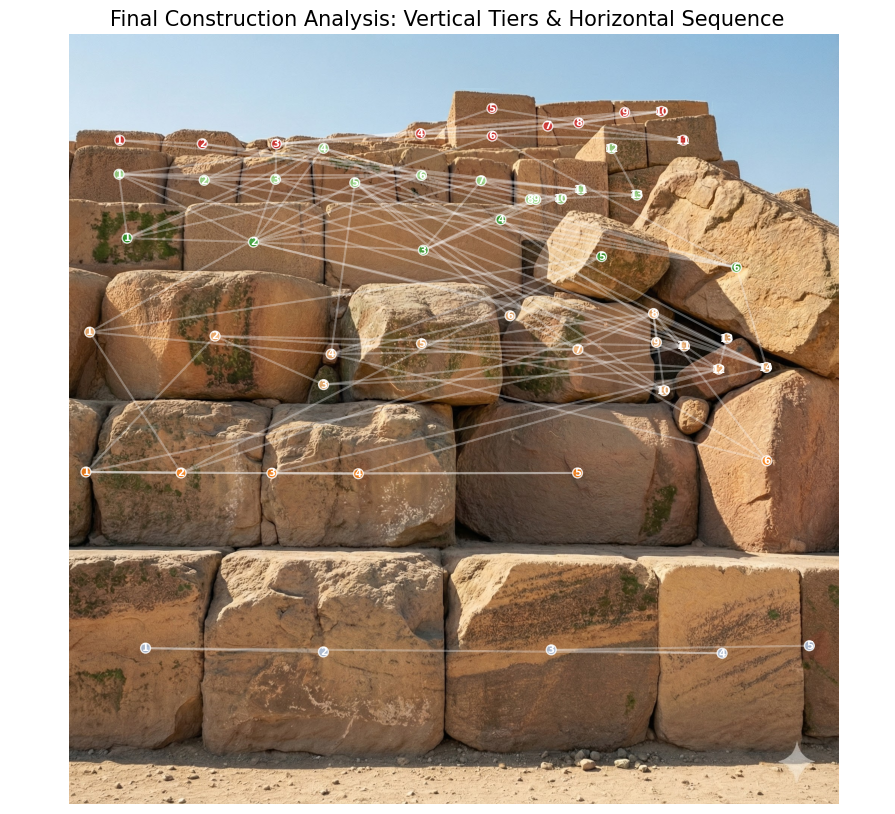

解析結果を stone_analysis_v4.csv に保存しました。


In [ ]:


# --- 4. 水平方向の解析ロジック（決定版） ---

def analyze_horizontal_order_v4(df_stones, masks, dilate_px=8):
    """
    df_stonesとmasksが1対1で対応していることを前提に、
    安全にインデックスを管理して隣接グラフを構築する。
    """
    print("\n--- 水平方向の解析（インデックス同期版）開始 ---")
    
    # 1. データフレームのインデックスを振り直し、マスクとの順序を固定する
    # main()から返された直後であれば、df_stonesのi行目はmasksのi番目に対応している
    df_working = df_stones.copy().reset_index(drop=True)
    
    # 2. 垂直方向の段(Tier)でグループ化した後、各段の中で左から順に並べる
    # 注意: ここでソートするとmasksとの順序が崩れるため、
    # masksの元の位置を保持するための 'original_idx' を作っておく
    df_working['original_idx'] = df_working.index 
    
    # 段(Tier) -> X座標 の順でソートして順位を決定
    df_sorted = df_working.sort_values(['Tier', 'Centroid_X']).copy()
    df_sorted['Horizontal_Rank'] = df_sorted.groupby('Tier').cumcount() + 1
    
    # 3. 隣接グラフの構築
    G = nx.Graph()
    for idx, row in df_sorted.iterrows():
        # 描画用に Stone_ID をノード名にする
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']), 
                   tier=row['Tier'], rank=row['Horizontal_Rank'])

    # 4. 隣接判定（元のインデックスを使用してマスクにアクセス）
    print(f"隣接関係を計算中... (対象石数: {len(df_sorted)})")
    
    # 効率のため、一度全マスクを膨張させたものをリスト化する
    dilated_masks = []
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for i in range(len(df_working)):
        m = masks[i]['segmentation'].astype(np.uint8)
        dilated_masks.append(cv2.dilate(m, kernel, iterations=1))

    # 二重ループで接触判定
    stone_rows = [row for _, row in df_sorted.iterrows()]
    for i in range(len(stone_rows)):
        row_i = stone_rows[i]
        idx_i = int(row_i['original_idx']) # 元のリスト位置
        id_i = row_i['Stone_ID']
        
        for j in range(i + 1, len(stone_rows)):
            row_j = stone_rows[j]
            idx_j = int(row_j['original_idx']) # 元のリスト位置
            id_j = row_j['Stone_ID']
            
            # 膨張させたマスクiと、通常のマスクjの重なりをチェック
            if np.any(np.logical_and(dilated_masks[idx_i], masks[idx_j]['segmentation'])):
                G.add_edge(id_i, id_j)

    return df_sorted, G

def visualize_horizontal_v4(image_rgb, G, df_stones, node_scale=0.4, edge_scale=0.5):
    """
    可視化関数。Stone_IDをベースにしたノード管理に対応。
    """
    fig, ax = plt.subplots(figsize=(15, 10))
    ax.imshow(image_rgb)
    
    pos = nx.get_node_attributes(G, 'pos')
    base_scale = image_rgb.shape[1] / 1000
    
    # エッジの描画
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, edge_color='white', 
                           width=1.5 * base_scale * edge_scale)
    
    # 石の描画
    for _, row in df_stones.iterrows():
        color = plt.cm.tab20(int(row['Tier']) % 20)
        radius = 16 * base_scale * node_scale
        circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, 
                            color=color, ec='white', lw=1, alpha=0.8, zorder=5)
        ax.add_patch(circle)
        
        # 順序番号の表示
        ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Horizontal_Rank'])), 
                color='white', ha='center', va='center', 
                fontsize=15 * base_scale * node_scale, fontweight='bold', zorder=6)
    

    plt.title("Final Construction Analysis: Vertical Tiers & Horizontal Sequence", fontsize=15)
    plt.axis('off')
    plt.show()

# --- 実行セル ---
if __name__ == "__main__":
    # current_masks と df が存在することを確認
    if 'current_masks' in locals() and 'df' in locals():
        # 1. 解析の実行 (v4を使用)
        df_final, G_horizontal = analyze_horizontal_order_v4(df, current_masks, dilate_px=10)
        
        # 2. 可視化
        img_path = "images/pyramid2_test.jpeg" # 実際のパスに
        if os.path.exists(img_path):
            image_bgr = cv2.imread(img_path)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            visualize_horizontal_v4(image_rgb, G_horizontal, df_final, node_scale=0.4, edge_scale=0.5)
            
            # CSV保存（卒論のデータとして）
            df_final.to_csv("stone_analysis_v4.csv", index=False)
            print("解析結果を stone_analysis_v4.csv に保存しました。")